Surge:
  - Change: -0.22 %
  + Change: 0.09 %
SLR:
  - Change: -0.05 %
  + Change: 0.05 %
River flow:
  - Change: 0.00 %
  + Change: 0.00 %
Bed roughness:
  - Change: -0.01 %
  + Change: 0.03 %


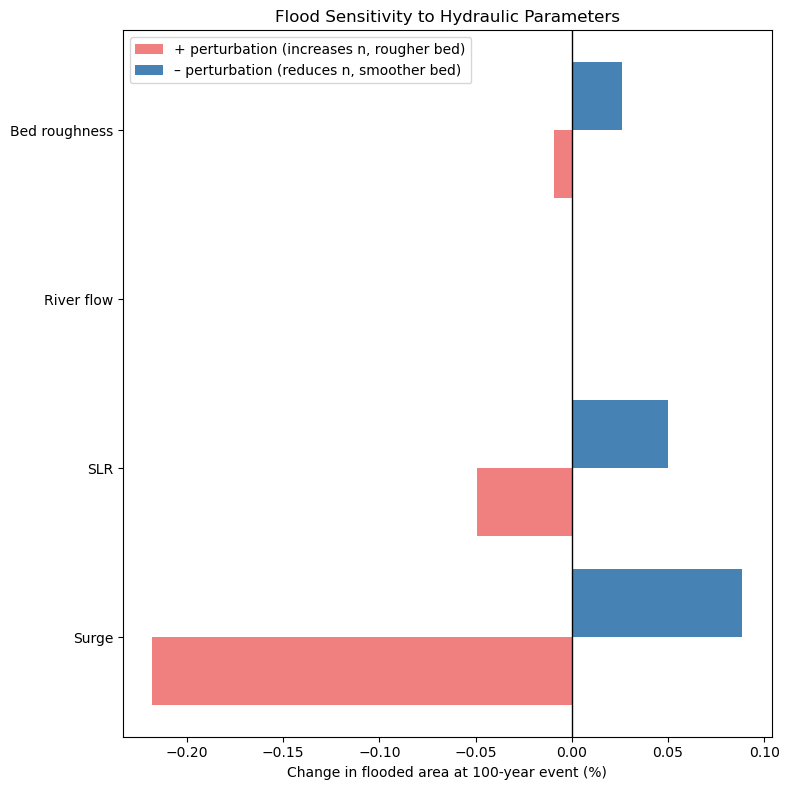

In [3]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os

# --- Config ---
THRESHOLD = 0.1  # Inundation threshold in meters
boundary_zip = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
shapefile_extract_path = r"D:\Phd Research\GIS\Shape\unzipped"
ref_file = r"D:\Phd Research\sim_depth_100yr.tif"

# Perturbed rasters for each parameter
perturbations = {
    'Surge': {
        '-': r"D:\Phd Research\sim_depth_100yr_surge_M10.tif",
        '+': r"D:\Phd Research\sim_depth_100yr_surge_P10.tif"
    },
    'SLR': {
        '-': r"D:\Phd Research\sim_depth_100yr_0.8SLR.tif",
        '+': r"D:\Phd Research\sim_depth_100yr_1.2SLR.tif"
    },
    'River flow': {
        '-': r"D:\Phd Research\sim_depth_100yr_surge_Q_M20.tif",
        '+': r"D:\Phd Research\sim_depth_100yr_surge_Q_P20.tif"
    },
    'Bed roughness': {
        '-': r"D:\Phd Research\sim_depth_100yr_surge_M20_Mannings.tif",
        '+': r"D:\Phd Research\sim_depth_100yr_surge_P20_Mannings.tif"
    },
}

# --- Step 1: Unzip shapefile ---
with zipfile.ZipFile(boundary_zip, 'r') as zip_ref:
    zip_ref.extractall(shapefile_extract_path)

shapefile = [os.path.join(shapefile_extract_path, f) for f in os.listdir(shapefile_extract_path) if f.endswith(".shp")][0]
gdf = gpd.read_file(shapefile)
geoms = gdf.geometry.values

# --- Function to get inundated area ---
def compute_extent(raster_path):
    with rasterio.open(raster_path) as src:
        out_image, out_transform = mask(src, geoms, crop=True)
        data = out_image[0]
        nodata = src.nodata
        if nodata is not None:
            data = np.ma.masked_equal(data, nodata)
        else:
            data = np.ma.masked_invalid(data)

        data = np.ma.masked_where(data <= THRESHOLD, data)
        inundated_pixels = np.sum(~data.mask)
        pixel_area = abs(src.res[0] * src.res[1])
        return inundated_pixels * pixel_area

# --- Reference extent ---
extent_0 = compute_extent(ref_file)

# --- Store results ---
params = []
change_minus = []
change_plus = []

# --- Compute % change for each parameter ---
for param, paths in perturbations.items():
    extent_minus = compute_extent(paths['-'])
    extent_plus = compute_extent(paths['+'])

    delta_minus = ((extent_minus - extent_0) / extent_0) * 100
    delta_plus = ((extent_plus - extent_0) / extent_0) * 100

    params.append(param)
    change_minus.append(delta_minus)
    change_plus.append(delta_plus)

    print(f"{param}:")
    print(f"  - Change: {delta_minus:.2f} %")
    print(f"  + Change: {delta_plus:.2f} %")

# --- Plotting ---
y = np.arange(len(params))

fig, ax = plt.subplots(figsize=(8, 8))

bar_width = 0.4
ax.barh(y - bar_width/2, change_minus, height=bar_width, color='lightcoral', label='+ perturbation (increases n, rougher bed)')
ax.barh(y + bar_width/2, change_plus, height=bar_width, color='steelblue', label='– perturbation (reduces n, smoother bed)')

ax.set_yticks(y)
ax.set_yticklabels(params)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel("Change in flooded area at 100-year event (%)")
ax.set_title("Flood Sensitivity to Hydraulic Parameters")
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


Surge:
  - Change: -0.31 %
  + Change: 0.15 %
SLR:
  - Change: -0.07 %
  + Change: 0.05 %
River flow:
  - Change: -0.00 %
  + Change: 0.00 %
Bed roughness:
  - Change: 0.05 %
  + Change: -0.04 %


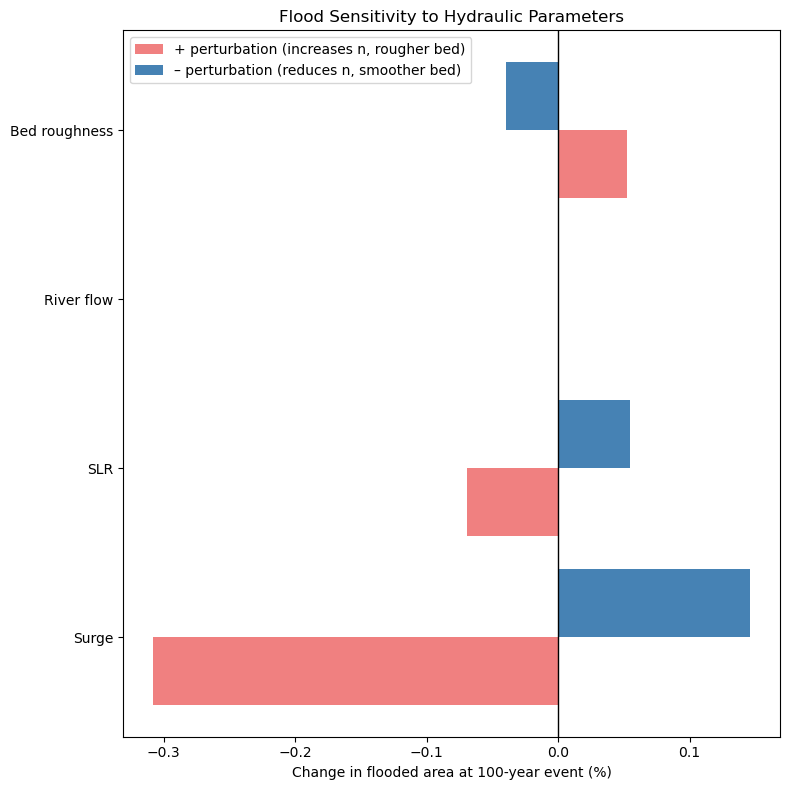

In [14]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os

# --- Config ---
THRESHOLD = 0.1  # Inundation threshold in meters
boundary_zip = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
shapefile_extract_path = r"D:\Phd Research\GIS\Shape\unzipped"
ref_file = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"

# Perturbed rasters for each parameter
perturbations = {
    'Surge': {
        '-': r"D:\Phd Research\Final_Raster\100yr_compound_flood_surge_M10_stat.tif",
        '+': r"D:\Phd Research\Final_Raster\100yr_compound_flood_surge_P10_stat.tif"
    },
    'SLR': {
        '-': r"D:\Phd Research\Final_Raster\100yr_compound_flood_SLR_M20_stat.tif",
        '+': r"D:\Phd Research\Final_Raster\100yr_compound_flood_SLR_P20_stat.tif"
    },
    'River flow': {
        '-': r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_Q_M20_stat.tif",
        '+': r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_Q_P_20_stat.tif"
    },
    'Bed roughness': {
        '-': r"D:\Phd Research\Final_Raster\100yr_Compound_flood_base_M_P20_stat.tif",
        '+': r"D:\Phd Research\Final_Raster\100yr_compound_flood_M_M20_stat.tif"
    },
}

# --- Step 1: Unzip shapefile ---
with zipfile.ZipFile(boundary_zip, 'r') as zip_ref:
    zip_ref.extractall(shapefile_extract_path)

shapefile = [os.path.join(shapefile_extract_path, f) for f in os.listdir(shapefile_extract_path) if f.endswith(".shp")][0]
gdf = gpd.read_file(shapefile)
geoms = gdf.geometry.values

# --- Function to get inundated area ---
def compute_extent(raster_path):
    with rasterio.open(raster_path) as src:
        out_image, out_transform = mask(src, geoms, crop=True)
        data = out_image[0]
        nodata = src.nodata
        if nodata is not None:
            data = np.ma.masked_equal(data, nodata)
        else:
            data = np.ma.masked_invalid(data)

        data = np.ma.masked_where(data <= THRESHOLD, data)
        inundated_pixels = np.sum(~data.mask)
        pixel_area = abs(src.res[0] * src.res[1])
        return inundated_pixels * pixel_area

# --- Reference extent ---
extent_0 = compute_extent(ref_file)

# --- Store results ---
params = []
change_minus = []
change_plus = []

# --- Compute % change for each parameter ---
for param, paths in perturbations.items():
    extent_minus = compute_extent(paths['-'])
    extent_plus = compute_extent(paths['+'])

    delta_minus = ((extent_minus - extent_0) / extent_0) * 100
    delta_plus = ((extent_plus - extent_0) / extent_0) * 100

    params.append(param)
    change_minus.append(delta_minus)
    change_plus.append(delta_plus)

    print(f"{param}:")
    print(f"  - Change: {delta_minus:.2f} %")
    print(f"  + Change: {delta_plus:.2f} %")

# --- Plotting ---
y = np.arange(len(params))

fig, ax = plt.subplots(figsize=(8, 8))

bar_width = 0.4
ax.barh(y - bar_width/2, change_minus, height=bar_width, color='lightcoral', label='+ perturbation (increases n, rougher bed)')
ax.barh(y + bar_width/2, change_plus, height=bar_width, color='steelblue', label='– perturbation (reduces n, smoother bed)')

ax.set_yticks(y)
ax.set_yticklabels(params)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel("Change in flooded area at 100-year event (%)")
ax.set_title("Flood Sensitivity to Hydraulic Parameters")
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


Surge:
  - Mean depth (ref):  4.4495 m
  - Mean depth (–):    3.7532 m  -> Δ% vs ref: -15.65%
  - Mean depth (+):    5.1370 m  -> Δ% vs ref: +15.45%
SLR:
  - Mean depth (ref):  4.4495 m
  - Mean depth (–):    4.2265 m  -> Δ% vs ref: -5.01%
  - Mean depth (+):    4.6758 m  -> Δ% vs ref: +5.09%
River flow:
  - Mean depth (ref):  4.4495 m
  - Mean depth (–):    4.4463 m  -> Δ% vs ref: -0.07%
  - Mean depth (+):    4.4526 m  -> Δ% vs ref: +0.07%
Bed roughness:
  - Mean depth (ref):  4.4495 m
  - Mean depth (–):    4.6166 m  -> Δ% vs ref: +3.76%
  - Mean depth (+):    4.2512 m  -> Δ% vs ref: -4.46%


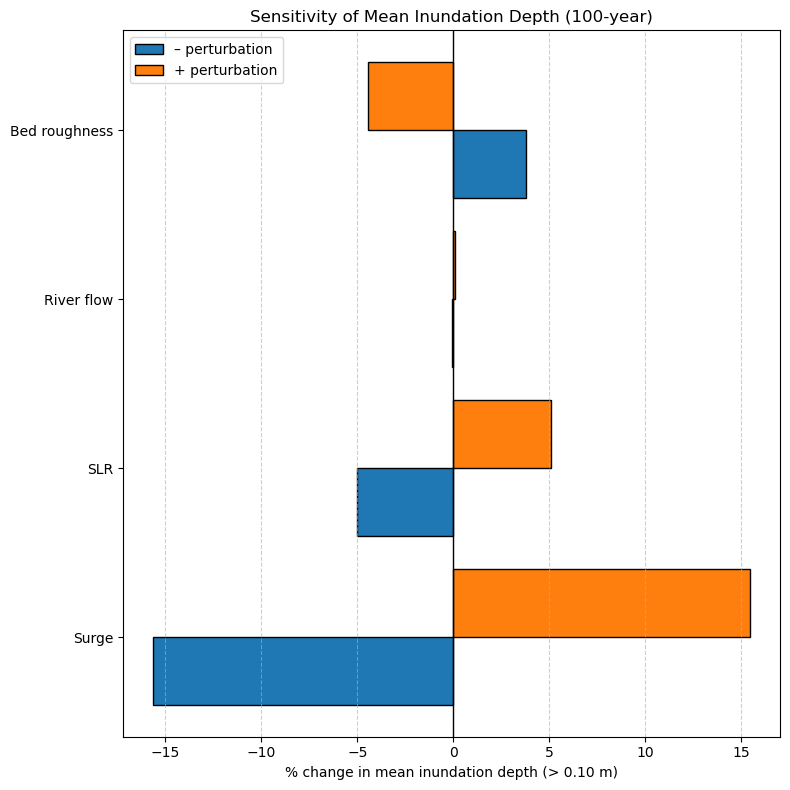

In [9]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os
import warnings

# --- Config ---
THRESHOLD = 0.1  # Inundation threshold in meters (cells <= THRESHOLD are ignored)
boundary_zip = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
shapefile_extract_path = r"D:\Phd Research\GIS\Shape\unzipped"

ref_file = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"

# Perturbed rasters for each parameter
perturbations = {
    'Surge': {
        '-': r"D:\Phd Research\Final_Raster\100yr_compound_flood_surge_M10_stat.tif",
        '+': r"D:\Phd Research\Final_Raster\100yr_compound_flood_surge_P10_stat.tif"
    },
    'SLR': {
        '-': r"D:\Phd Research\Final_Raster\100yr_compound_flood_SLR_M20_stat.tif",
        '+': r"D:\Phd Research\Final_Raster\100yr_compound_flood_SLR_P20_stat.tif"
    },
    'River flow': {
        '-': r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_Q_M20_stat.tif",
        '+': r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_Q_P_20_stat.tif"
    },
    'Bed roughness': {
        '-': r"D:\Phd Research\Final_Raster\100yr_Compound_flood_base_M_P20_stat.tif",
        '+': r"D:\Phd Research\Final_Raster\100yr_compound_flood_M_M20_stat.tif"
    },
}

# --- Step 1: Unzip shapefile (if needed) ---
if not os.path.isdir(shapefile_extract_path) or not any(f.endswith(".shp") for f in os.listdir(shapefile_extract_path)):
    with zipfile.ZipFile(boundary_zip, 'r') as zip_ref:
        zip_ref.extractall(shapefile_extract_path)

shapefile = [os.path.join(shapefile_extract_path, f)
             for f in os.listdir(shapefile_extract_path) if f.endswith(".shp")][0]
gdf_boundary = gpd.read_file(shapefile)

# --- Function: mean depth over wet cells (>THRESHOLD) within boundary ---
def mean_depth_over_wet(raster_path, threshold=THRESHOLD):
    with rasterio.open(raster_path) as src:
        # Reproject boundary to raster CRS for accurate masking
        boundary_in_src = gdf_boundary.to_crs(src.crs)

        # Clip to boundary; keep masked array (filled=False) for valid mask handling
        out, out_transform = mask(src, boundary_in_src.geometry, crop=True, filled=False, all_touched=True)
        data = out[0]  # MaskedArray

        # Build wet mask: valid and > threshold
        valid = ~data.mask & np.isfinite(data)
        wet = valid & (data > threshold)

        if wet.sum() == 0:
            return np.nan  # no wet pixels above threshold

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)  # silence mean of empty slice if any
            return float(data[wet].mean())

# --- Reference mean depth ---
mean_ref = mean_depth_over_wet(ref_file)

# --- Compute % change in mean depth for each parameter ---
params = []
change_minus = []
change_plus = []

for param, paths in perturbations.items():
    mean_minus = mean_depth_over_wet(paths['-'])
    mean_plus  = mean_depth_over_wet(paths['+'])

    # % change relative to reference mean depth
    if np.isfinite(mean_ref) and mean_ref != 0.0:
        delta_minus = ((mean_minus - mean_ref) / mean_ref) * 100.0 if np.isfinite(mean_minus) else np.nan
        delta_plus  = ((mean_plus  - mean_ref) / mean_ref) * 100.0 if np.isfinite(mean_plus)  else np.nan
    else:
        delta_minus = np.nan
        delta_plus  = np.nan

    params.append(param)
    change_minus.append(delta_minus)
    change_plus.append(delta_plus)

    print(f"{param}:")
    print(f"  - Mean depth (ref):  {mean_ref:.4f} m")
    print(f"  - Mean depth (–):    {mean_minus:.4f} m  -> Δ% vs ref: {delta_minus:+.2f}%")
    print(f"  - Mean depth (+):    {mean_plus:.4f} m  -> Δ% vs ref: {delta_plus:+.2f}%")

# --- Plotting: X = % change of mean depth ---
y = np.arange(len(params))
fig, ax = plt.subplots(figsize=(8, 8))

bar_width = 0.4
ax.barh(y - bar_width/2, change_minus, height=bar_width, edgecolor='black', label='– perturbation')
ax.barh(y + bar_width/2, change_plus,  height=bar_width, edgecolor='black', label='+ perturbation')

ax.set_yticks(y)
ax.set_yticklabels(params)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel("% change in mean inundation depth (> {:.2f} m)".format(THRESHOLD))
ax.set_title("Sensitivity of Mean Inundation Depth (100-year)")
ax.grid(axis="x", linestyle="--", alpha=0.6)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()


Surge:
  - scenario change: -0.31 %
  + scenario change: 0.15 %
SLR:
  - scenario change: -0.07 %
  + scenario change: 0.05 %
Bed roughness:
  - scenario change: 0.05 %
  + scenario change: -0.04 %


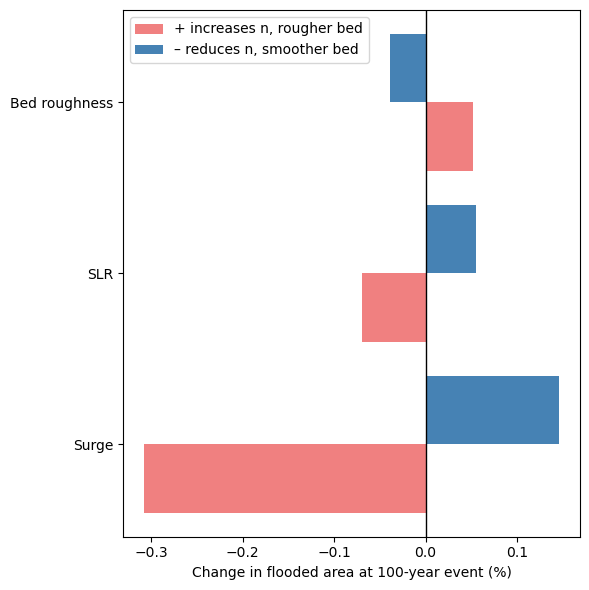

In [7]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os

# --- Config ---
THRESHOLD = 0.1  # Inundation threshold in meters
boundary_zip = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
shapefile_extract_path = r"D:\Phd Research\GIS\Shape\unzipped"
ref_file = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"

# Perturbed rasters for each parameter (River flow removed)
perturbations = {
    'Surge': {
        '-': r"D:\Phd Research\Final_Raster\100yr_compound_flood_surge_M10_stat.tif",
        '+': r"D:\Phd Research\Final_Raster\100yr_compound_flood_surge_P10_stat.tif"
    },
    'SLR': {
        '-': r"D:\Phd Research\Final_Raster\100yr_compound_flood_SLR_M20_stat.tif",
        '+': r"D:\Phd Research\Final_Raster\100yr_compound_flood_SLR_P20_stat.tif"
    },
    'Bed roughness': {
        '-': r"D:\Phd Research\Final_Raster\100yr_Compound_flood_base_M_P20_stat.tif",
        '+': r"D:\Phd Research\Final_Raster\100yr_compound_flood_M_M20_stat.tif"
    },
}

# --- Step 1: Unzip shapefile (once is enough; harmless if already extracted) ---
with zipfile.ZipFile(boundary_zip, 'r') as zip_ref:
    zip_ref.extractall(shapefile_extract_path)

shapefile = [os.path.join(shapefile_extract_path, f) for f in os.listdir(shapefile_extract_path) if f.endswith(".shp")][0]
gdf = gpd.read_file(shapefile)
geoms = gdf.geometry.values

# --- Function to get inundated area (m^2) for a raster clipped to boundary ---
def compute_extent(raster_path):
    with rasterio.open(raster_path) as src:
        out_image, out_transform = mask(src, geoms, crop=True)
        data = out_image[0]
        nodata = src.nodata
        if nodata is not None:
            data = np.ma.masked_equal(data, nodata)
        else:
            data = np.ma.masked_invalid(data)

        # Keep pixels above threshold
        data = np.ma.masked_where(data <= THRESHOLD, data)

        inundated_pixels = np.sum(~data.mask)
        pixel_area = abs(src.res[0] * src.res[1])  # m^2
        return inundated_pixels * pixel_area

# --- Reference extent ---
extent_0 = compute_extent(ref_file)

# --- Store results ---
params = []
change_minus = []
change_plus = []

# --- Compute % change for each parameter ---
for param, paths in perturbations.items():
    extent_minus = compute_extent(paths['-'])
    extent_plus  = compute_extent(paths['+'])

    delta_minus = ((extent_minus - extent_0) / extent_0) * 100.0
    delta_plus  = ((extent_plus  - extent_0) / extent_0) * 100.0

    params.append(param)
    change_minus.append(delta_minus)
    change_plus.append(delta_plus)

    print(f"{param}:")
    print(f"  - scenario change: {delta_minus:.2f} %")
    print(f"  + scenario change: {delta_plus:.2f} %")

# --- Plotting ---
y = np.arange(len(params))
fig, ax = plt.subplots(figsize=(6,6))

bar_width = 0.4
ax.barh(y - bar_width/2, change_minus, height=bar_width, color='lightcoral', label='+ increases n, rougher bed')
ax.barh(y + bar_width/2, change_plus,  height=bar_width, color='steelblue',  label='– reduces n, smoother bed')

ax.set_yticks(y)
ax.set_yticklabels(params)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel("Change in flooded area at 100-year event (%)")
# ax.set_title("Flood Sensitivity to Hydraulic Parameters (No River Flow)")
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


Surge:
  - Mean depth (ref):  4.4495 m
  - Mean depth (–):    3.7532 m  -> Δ% vs ref: -15.65%
  - Mean depth (+):    5.1370 m  -> Δ% vs ref: +15.45%
SLR:
  - Mean depth (ref):  4.4495 m
  - Mean depth (–):    4.2265 m  -> Δ% vs ref: -5.01%
  - Mean depth (+):    4.6758 m  -> Δ% vs ref: +5.09%
River flow:
  - Mean depth (ref):  4.4495 m
  - Mean depth (–):    4.4463 m  -> Δ% vs ref: -0.07%
  - Mean depth (+):    4.4526 m  -> Δ% vs ref: +0.07%
Bed roughness:
  - Mean depth (ref):  4.4495 m
  - Mean depth (–):    4.6166 m  -> Δ% vs ref: +3.76%
  - Mean depth (+):    4.2512 m  -> Δ% vs ref: -4.46%


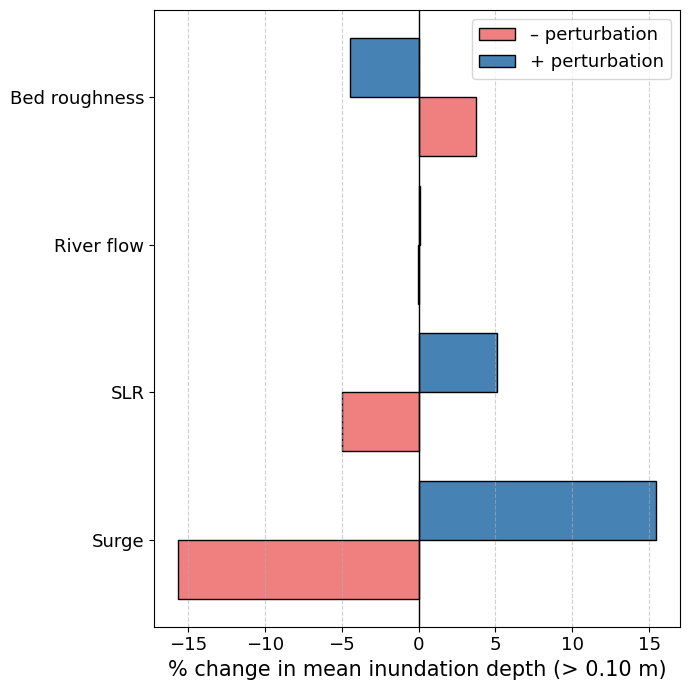

In [12]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os
import warnings

# --- Config ---
THRESHOLD = 0.1  # Inundation threshold in meters (cells <= THRESHOLD are ignored)
boundary_zip = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
shapefile_extract_path = r"D:\Phd Research\GIS\Shape\unzipped"

ref_file = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"

# Perturbed rasters for each parameter
perturbations = {
    'Surge': {
        '-': r"D:\Phd Research\Final_Raster\100yr_compound_flood_surge_M10_stat.tif",
        '+': r"D:\Phd Research\Final_Raster\100yr_compound_flood_surge_P10_stat.tif"
    },
    'SLR': {
        '-': r"D:\Phd Research\Final_Raster\100yr_compound_flood_SLR_M20_stat.tif",
        '+': r"D:\Phd Research\Final_Raster\100yr_compound_flood_SLR_P20_stat.tif"
    },
    'River flow': {
        '-': r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_Q_M20_stat.tif",
        '+': r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_Q_P_20_stat.tif"
    },
    'Bed roughness': {
        '-': r"D:\Phd Research\Final_Raster\100yr_Compound_flood_base_M_P20_stat.tif",
        '+': r"D:\Phd Research\Final_Raster\100yr_compound_flood_M_M20_stat.tif"
    },
}

# --- Step 1: Unzip shapefile (if needed) ---
if not os.path.isdir(shapefile_extract_path) or not any(f.endswith(".shp") for f in os.listdir(shapefile_extract_path)):
    with zipfile.ZipFile(boundary_zip, 'r') as zip_ref:
        zip_ref.extractall(shapefile_extract_path)

shapefile = [os.path.join(shapefile_extract_path, f)
             for f in os.listdir(shapefile_extract_path) if f.endswith(".shp")][0]
gdf_boundary = gpd.read_file(shapefile)

# --- Function: mean depth over wet cells (>THRESHOLD) within boundary ---
def mean_depth_over_wet(raster_path, threshold=THRESHOLD):
    with rasterio.open(raster_path) as src:
        boundary_in_src = gdf_boundary.to_crs(src.crs)
        out, out_transform = mask(src, boundary_in_src.geometry, crop=True, filled=False, all_touched=True)
        data = out[0]  # MaskedArray

        valid = ~data.mask & np.isfinite(data)
        wet = valid & (data > threshold)

        if wet.sum() == 0:
            return np.nan

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            return float(data[wet].mean())

# --- Reference mean depth ---
mean_ref = mean_depth_over_wet(ref_file)

# --- Compute % change in mean depth for each parameter ---
params, change_minus, change_plus = [], [], []

for param, paths in perturbations.items():
    mean_minus = mean_depth_over_wet(paths['-'])
    mean_plus  = mean_depth_over_wet(paths['+'])

    if np.isfinite(mean_ref) and mean_ref != 0.0:
        delta_minus = ((mean_minus - mean_ref) / mean_ref) * 100.0 if np.isfinite(mean_minus) else np.nan
        delta_plus  = ((mean_plus  - mean_ref) / mean_ref) * 100.0 if np.isfinite(mean_plus)  else np.nan
    else:
        delta_minus, delta_plus = np.nan, np.nan

    params.append(param)
    change_minus.append(delta_minus)
    change_plus.append(delta_plus)

    print(f"{param}:")
    print(f"  - Mean depth (ref):  {mean_ref:.4f} m")
    print(f"  - Mean depth (–):    {mean_minus:.4f} m  -> Δ% vs ref: {delta_minus:+.2f}%")
    print(f"  - Mean depth (+):    {mean_plus:.4f} m  -> Δ% vs ref: {delta_plus:+.2f}%")

# --- Plotting: X = % change of mean depth ---
y = np.arange(len(params))
fig, ax = plt.subplots(figsize=(7, 7))

bar_width = 0.4
ax.barh(y - bar_width/2, change_minus, height=bar_width, edgecolor='black', color='lightcoral', label='– perturbation')
ax.barh(y + bar_width/2, change_plus,  height=bar_width, edgecolor='black', color='steelblue', label='+ perturbation')

# --- Style and larger text ---
ax.set_yticks(y)
ax.set_yticklabels(params, fontsize=13)
ax.axvline(x=0, color='black', linewidth=1)

ax.set_xlabel("% change in mean inundation depth (> {:.2f} m)".format(THRESHOLD), fontsize=15)
# ax.set_title("Sensitivity of Mean Inundation Depth (100-year)", fontsize=18, weight='bold')
ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.grid(axis="x", linestyle="--", alpha=0.6)

legend = ax.legend(loc='upper right', fontsize=13, frameon=True)
for text in legend.get_texts():
    text.set_fontsize(13)

plt.tight_layout()
plt.show()
